# Analyse et prédiction du marché de l'emploi

## Présentation du Notebook
Ce notebook a pour objectif d’analyser et de prédire le taux de chômage à partir de données économiques nationales, notamment le PIB, la structure sectorielle de l’emploi et le pays concerné. En utilisant des techniques avancées de machine learning, notre démarche intègre la préparation des données, leur exploration, et le développement de modèles afin d’identifier les principaux déterminants du chômage et d’obtenir des prédictions fiables. Ce travail s’appuie sur un jeu de données international couvrant plus de 180 pays sur la période 1991-2022.

## Dataset
- **Nom:** Global Jobs, GDP & Unemployment (1991–2022)
- **Source:** Kaggle
- **Lien:** https://www.kaggle.com/datasets/akshatsharma2/global-jobs-gdp-and-unemployment-data-19912022






## 1. Import des bibliothèques


In [ ]:

# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Préprocessing et pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score


# Modèle XGBoost
import xgboost as xgb



## 2. Chargement du dataset


In [ ]:
df = pd.read_csv("../ML/data/Employment_Unemployment_GDP_data.csv")
df.head()


,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
0,Albania,1991,53.299533,12.172764,34.527781,10.304,1.099559e+09
1,Algeria,1991,24.118566,25.067734,50.813700,20.600,4.571568e+10
2,Angola,1991,40.071857,8.163345,51.764822,16.855,1.060378e+10
3,Argentina,1991,13.669999,28.505903,57.824098,5.440,1.897200e+11
4,Armenia,1991,54.263252,15.790454,29.946294,1.783,2.069870e+09


## 3. Exploration des données
Cette phase permet de comprendre la structure, les types de colonnes, les valeurs manquantes et les distributions.

In [ ]:
# Information générales sur le dataset
print("Dimensions du dataset:", df.shape)
print("Colonnes:", df.columns)
print(df.info())
print(df.isnull().sum())
print(df.describe())


Dimensions du dataset: (5751, 7)
Colonnes: Index(['Country Name', 'Year', 'Employment Sector: Agriculture',
       'Employment Sector: Industry', 'Employment Sector: Services',
       'Unemployment Rate', 'GDP (in USD)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5751 entries, 0 to 5750
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    5751 non-null   object 
 1   Year                            5751 non-null   int64  
 2   Employment Sector: Agriculture  5751 non-null   float64
 3   Employment Sector: Industry     5751 non-null   float64
 4   Employment Sector: Services     5751 non-null   float64
 5   Unemployment Rate               5751 non-null   float64
 6   GDP (in USD)                    5751 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 314.6+ KB
None
Country Name                    

     country  year  agriculture   industry   services  unemployment_rate  \
0    Albania  1991    53.299533  12.172764  34.527781             10.304   
1    Algeria  1991    24.118566  25.067734  50.813700             20.600   
2     Angola  1991    40.071857   8.163345  51.764822             16.855   
3  Argentina  1991    13.669999  28.505903  57.824098              5.440   
4    Armenia  1991    54.263252  15.790454  29.946294              1.783   

            gdp  
0  1.099559e+09  
1  4.571568e+10  
2  1.060378e+10  
3  1.897200e+11  
4  2.069870e+09  


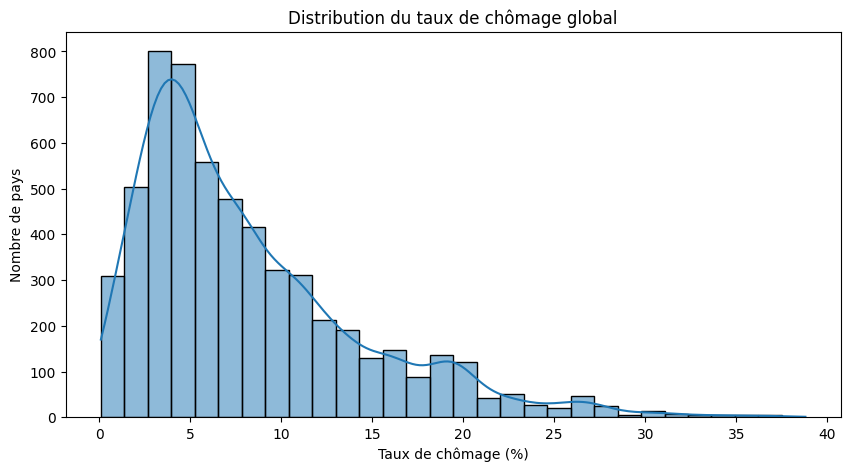

In [ ]:
# 4. Renommer les colonnes pour simplifier l'accès

df.rename(columns={
    'Country Name': 'country',
    'Year': 'year',
    'Employment Sector: Agriculture': 'agriculture',
    'Employment Sector: Industry': 'industry',
    'Employment Sector: Services': 'services',
    'Unemployment Rate': 'unemployment_rate',
    'GDP (in USD)': 'gdp'
}, inplace=True)

# Vérification
print(df.head())

# 5. Visualisation du taux de chômage global
plt.figure(figsize=(10,5))
sns.histplot(df['unemployment_rate'], kde=True, bins=30)
plt.title('Distribution du taux de chômage global')
plt.xlabel('Taux de chômage (%)')
plt.ylabel('Nombre de pays')
plt.show()

* La majorité des pays ont un chômage faible à modéré (~4–12%).

* Très peu de pays ont un chômage très élevé (>25%).

* La distribution est asymétrique à droite (longue queue vers les valeurs élevées).



## 4. Préparation et nettoyage des données
- Gestion des valeurs manquantes et aberrantes
- Conversion des colonnes nécessaires



In [ ]:
# Vérification des valeurs manquantes
missing_values = df.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values)

# Vérification des doublons
duplicates = df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

# Statistiques de base pour détecter les valeurs aberrantes
print(df.describe())


Valeurs manquantes par colonne :
 country              0
year                 0
agriculture          0
industry             0
services             0
unemployment_rate    0
gdp                  0
dtype: int64
Nombre de doublons : 0
              year  agriculture     industry     services  unemployment_rate  \
count  5751.000000  5751.000000  5751.000000  5751.000000        5751.000000   
mean   2006.568945    28.857051    19.773784    51.369166           8.155004   
std       9.175548    24.026669     8.606954    18.892155           6.147428   
min    1991.000000     0.107774     2.060372     5.314014           0.100000   
25%    1999.000000     7.173214    13.889285    36.846735           3.659000   
50%    2007.000000    22.172104    20.105516    52.657618           6.358000   
75%    2014.000000    46.130703    25.345213    66.602313          10.996000   
max    2022.000000    92.482036    59.579079    93.416932          38.800000   

                gdp  
count  5.751000e+03  
mean

Stratégie adoptée :

Les valeurs extrêmes sont réalistes (ex. pays très agricoles ou avec chômage très élevé), donc on ne les supprime pas, mais on peut log-transformer gdp.

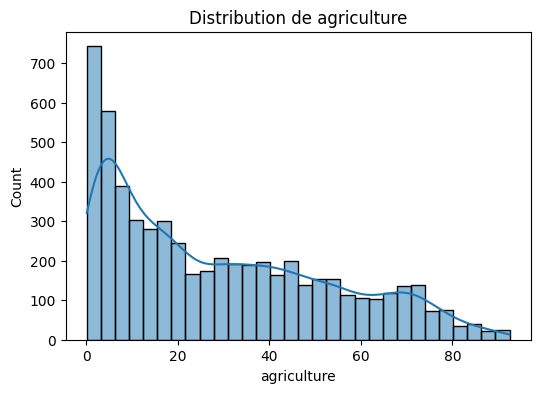

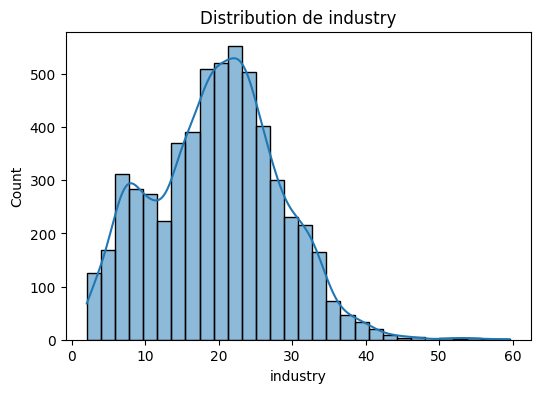

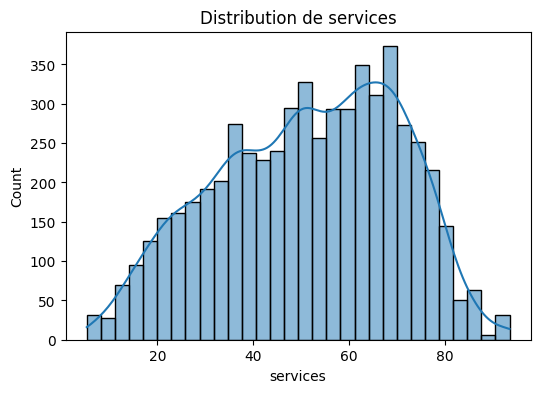

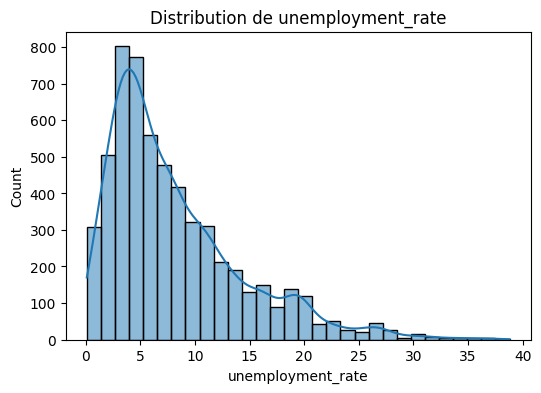

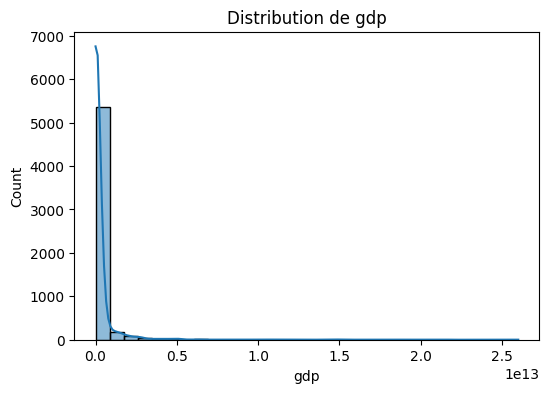

In [ ]:
numeric_cols = ['agriculture', 'industry', 'services', 'unemployment_rate', 'gdp']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
    plt.show()

La transformation log est necessaire pour réduire l’asymétrie des valeurs très élevées du PIB. Elle permet de stabiliser la variance et améliorer la performance du modèle.

In [ ]:
# 2. Transformation du PIB
df['gdp_log'] = np.log1p(df['gdp'])  # log(1 + PIB)


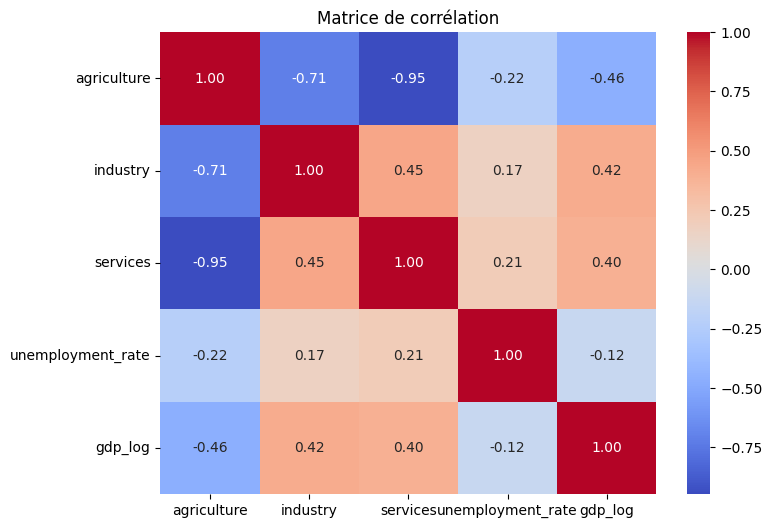

In [ ]:
# matrice de corrélation

df['gdp_log'] = np.log1p(df['gdp'])
corr_matrix = df[['agriculture', 'industry', 'services', 'unemployment_rate', 'gdp_log']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


# 5. Pipeline du modèle ML 

Le modèle développé vise à prédire le taux de chômage (unemployment_rate) pour chaque pays et chaque année en utilisant des indicateurs économiques et sectoriels. Les variables indépendantes comprennent la répartition de l’emploi par secteur (agriculture, industry, services), le PIB ajusté par logarithme (gdp_log), l’année (year) et le pays (country).  

Le choix du modèle s’est porté sur XGBoost Regressor, un algorithme d’arbres de décision boosting, capable de gérer les distributions asymétriques, les valeurs extrêmes et les relations non-linéaires entre les variables. Le pipeline intègre un prétraitement complet : standardisation des variables numériques, encodage one-hot des variables catégorielles (Dummies variables pour le pays) et log-transformation du PIB pour réduire l’asymétrie. Ce modèle permet non seulement de prédire le chômage avec précision, mais aussi d’identifier l’influence relative de chaque facteur économique, offrant ainsi une vision complète et interprétable du marché de l’emploi au niveau mondial.


### Explication du modèle

**unemployment_rate =fXGBoost​(agriculture,industry,services,gdp_log,year,country)**

Agriculture, Industrie, Services : représentent la structure de l’emploi dans l’économie d’un pays.

Par exemple, un pays très agricole a souvent un chômage plus volatil et moins d’emplois stables, tandis qu’une économie tournée vers l’industrie ou les services tend à avoir un chômage plus modéré.

PIB (gdp_log) : reflète la richesse et la taille de l’économie.

Un PIB élevé est souvent corrélé à une économie diversifiée, plus d’emplois et donc un chômage généralement plus faible.

Année (year) : permet de capturer les cycles économiques et crises globales (ex. crise 2008, pandémie 2020).

Pays (country) : capture les différences structurelles, politiques, sociales et réglementaires qui influencent le chômage.

In [ ]:
# 3. Définition des features et target
numeric_features = ['agriculture', 'industry', 'services', 'gdp_log', 'year']
categorical_features = ['country']
features = numeric_features + categorical_features
target = 'unemployment_rate'


# 4. Préprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


# 5. Séparation train/test
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 6. Modèle XGBoost
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)


# 7. Pipeline complet
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model)
])


# 8. Entraînement du modèle
pipeline.fit(X_train, y_train)

# 9. Évaluation sur le jeu de test
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")



Mean Squared Error: 6.1165
R2 Score: 0.8459


In [ ]:
print("Taille du train :", X_train.shape, y_train.shape)
print("Taille du test :", X_test.shape, y_test.shape)


Taille du train : (4600, 6) (4600,)
Taille du test : (1151, 6) (1151,)


In [ ]:
# Prédictions sur l'ensemble d'entraînement
y_train_pred = pipeline.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Déjà calculé pour le test (y_pred)
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"MSE entraînement : {mse_train:.4f}")
print(f"R² entraînement : {r2_train:.4f}")
print(f"MSE test : {mse_test:.4f}")
print(f"R² test : {r2_test:.4f}")


MSE entraînement : 5.6001
R² entraînement : 0.8499
MSE test : 6.1165
R² test : 0.8459


**Interprétation**  

L’écart très faible entre les performances d’entraînement et de test suggère qu’il n’y a pas de sur-apprentissage (overfitting) : le modèle apprend bien la structure des données sans mémoriser les exemples spécifiques.

Un R² proche de 0.85 indique une très bonne capacité à expliquer la variance de la variable cible (taux de chômage) par les variables explicatives.

Un MSE faible et similaire entre les deux ensembles confirme la stabilité du modèle.

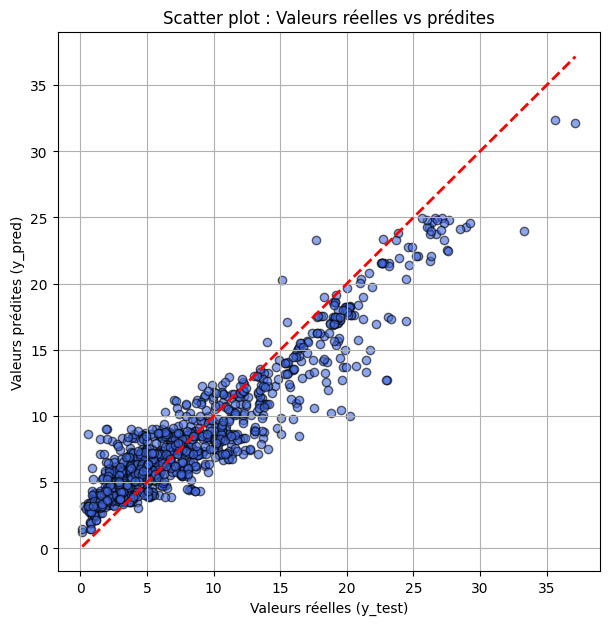

In [ ]:

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valeurs réelles (y_test)")
plt.ylabel("Valeurs prédites (y_pred)")
plt.title("Scatter plot : Valeurs réelles vs prédites")
plt.grid(True)
plt.show()



La plupart des points sont bien alignés le long de la diagonale, ce qui indique que les prédictions du modèle suivent globalement les valeurs réelles de taux de chômage.

Quelques écarts/sous-estimations pour les valeurs élevées (dans le coin supérieur droit), ce qui est typique : les modèles peuvent sous-prédire les extrêmes.

Cela confirme une bonne capacité de généralisation, cohérente avec le R² autour de 0.85 sur le jeu de test.

# Sauvgarde du modèle 

In [ ]:
import joblib

# Sauvegarder le pipeline entraîné
joblib.dump(pipeline, '/models/unemployment_model_xgboost_pipeline.joblib')


['modele_xgboost_pipeline.joblib']



## 9. Conclusion

Les résultats obtenus démontrent la capacité du modèle XGBoost à prédire le taux de chômage avec une performance stable (R² ≈ 0.85) et une bonne généralisation. Les variables explicatives retenues jouent un rôle déterminant, et le pipeline utilisé garantit une approche reproductible et robuste. L’analyse visuelle confirme la qualité des prédictions, bien qu’une sous-évaluation des extrêmes apparaisse.

**Limites et biais potentiels**  

Effets dynamiques : Le modèle ne prend pas en compte les effets retardés ou de causalité différée entre certaines variables. L’introduction de variables « laggées » dans une future version pourrait permettre une modélisation plus fine des dynamiques.

Biais de sélection : Les disparités structurelles propres à chaque pays, ou la qualité inégale des données, peuvent introduire des biais de prédiction.

Facteurs non observés : D’autres variables importantes (facteurs sociaux, réglementaires, chocs exogènes) ne sont pas incluses, ce qui limite la portée des prédictions.

Perspectives et améliorations
Enrichissement du modèle : Inclure des lags temporels et de nouvelles variables explicatives (éducation, inflation…).

Utilisation opérationnelle : Étendre l’application à d’autres indicateurs économiques ou à des analyses prospectives pour l’aide à la décision.

Ce travail constitue une base solide pour des analyses plus approfondies et pour l’intégration de nouvelles données économiques et méthodologies.

